## Preprocessing Overview

The goal of this notebook is to get the clean Airbnb demand dataset ready for modeling.

Most of the major cleaning already happened in the data wrangling and EDA notebooks. At this point, I am checking the target, selecting features, reviewing amenity columns, and preparing the dataset for train-test splitting.

The target is `reviews_per_month`, which I'm using in place of booking data to determine demand. Since missing or zero review activity does not give a clear demand signal, those listings were removed before this notebook.

### Steps Completed

- Loaded the clean demand dataset from the EDA notebook.
- Checked that `reviews_per_month` has no missing or zero values.
- Used `np.log1p()` on `reviews_per_month` to reduce skew.
- Selected baseline features, including property size, location, host signals, booking settings, and review score.
- Reviewed amenity columns and kept amenities that appeared often enough to be useful.
- Used one-hot encoded room type columns created during data wrangling.
- Used binary amenity columns created during data wrangling.
- Scaled numeric features for models like Ridge and Lasso.
- Split the data into training and testing sets so model performance can be checked on unseen data.

## Imports 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load Clean Data

In [2]:
df = pd.read_csv('../data/processed/airbnb_eda_clean.csv')

## Inspect Dataset

In [3]:
df.head()

,id,host_id,room_type_hotel_room,room_type_private_room,room_type_shared_room,accommodates,bedrooms,beds,bathrooms,host_is_superhost,...,amenity_wifi,amenity_workspace,city,price_log,number_of_reviews_log,beds_log,accommodates_log,bedrooms_log,bathrooms_log,room_type
0,108061,320564,0,0,0,2,1.0,1.0,1.0,1.0,...,1,0,Asheville,4.615121,4.532599,0.693147,1.098612,0.693147,0.693147,Entire home/apt
1,155305,746673,0,0,0,2,1.0,1.0,1.0,0.0,...,1,0,Asheville,4.615121,5.950643,0.693147,1.098612,0.693147,0.693147,Entire home/apt
2,156805,746673,0,1,0,2,1.0,1.0,2.5,0.0,...,1,0,Asheville,4.204693,4.219508,0.693147,1.098612,0.693147,1.252763,Private room
3,197263,961396,0,1,0,2,1.0,1.0,1.0,1.0,...,1,1,Asheville,3.828641,4.204693,0.693147,1.098612,0.693147,0.693147,Private room
4,209068,1029919,0,0,0,4,1.0,2.0,1.0,1.0,...,1,1,Asheville,4.615121,4.110874,1.098612,1.609438,0.693147,0.693147,Entire home/apt


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 210525 entries, 0 to 210524
Data columns (total 82 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   id                             210525 non-null  int64  
 1   host_id                        210525 non-null  int64  
 2   room_type_hotel_room           210525 non-null  int64  
 3   room_type_private_room         210525 non-null  int64  
 4   room_type_shared_room          210525 non-null  int64  
 5   accommodates                   210525 non-null  int64  
 6   bedrooms                       210525 non-null  float64
 7   beds                           210525 non-null  float64
 8   bathrooms                      210525 non-null  float64
 9   host_is_superhost              210525 non-null  float64
 10  host_response_time_ord         210525 non-null  float64
 11  price                          210525 non-null  float64
 12  latitude                       210525 non

In [5]:
df.shape

(210525, 82)

In [6]:
# checking that the demand target is clean before preprocessing
print('Missing reviews_per_month:', df['reviews_per_month'].isna().sum())
print('Zero reviews_per_month:', (df['reviews_per_month'] == 0).sum())
print('Minimum reviews_per_month:', df['reviews_per_month'].min())
print('Maximum reviews_per_month:', df['reviews_per_month'].max())

Missing reviews_per_month: 0
Zero reviews_per_month: 0
Minimum reviews_per_month: 0.01
Maximum reviews_per_month: 101.42


## Define Target

The target is `reviews_per_month`, which I am using as a proxy for Airbnb demand.

This notebook uses the clean demand dataset, so listings with missing or zero reviews per month have already been removed. I am using `np.log1p()` because the target is still right-skewed.

In [7]:
# using log-transformed reviews per month as the demand target
y = np.log1p(df['reviews_per_month'])

In [8]:
y.describe()

count    210525.000000
mean          0.784906
std           0.569582
min           0.009950
25%           0.277632
50%           0.693147
75%           1.214913
max           4.629082
Name: reviews_per_month, dtype: float64

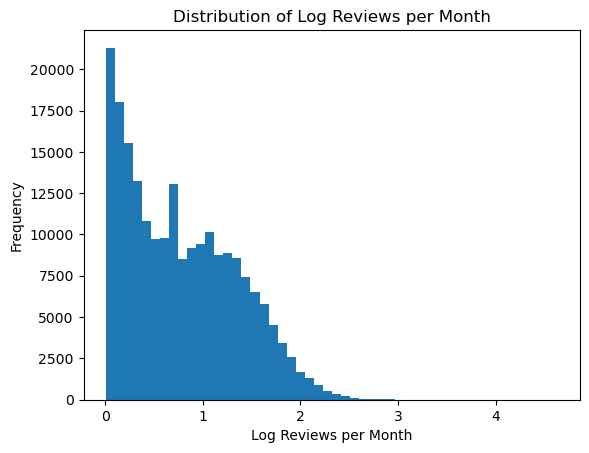

In [9]:
plt.hist(y, bins=50)
plt.title('Distribution of Log Reviews per Month')
plt.xlabel('Log Reviews per Month')
plt.ylabel('Frequency')
plt.show()

# checking the target distribution before modeling
# clearly skewed - could run another model on active listings with reviews > 0, but will leave as is for now. 

## Feature Selection 

In [10]:
# selecting core listing features for the baseline model
features = [
    'accommodates',
    'bedrooms',
    'beds',
    'bathrooms',
    'latitude',
    'longitude',
    'host_is_superhost',
    'instant_bookable',
    'review_scores_rating']

X = df[features]

In [11]:
X.describe()

,accommodates,bedrooms,beds,bathrooms,latitude,longitude,host_is_superhost,instant_bookable,review_scores_rating
count,210525.000000,210525.000000,210525.000000,210525.000000,210525.000000,210525.000000,210525.000000,210525.000000,210525.000000
mean,4.260382,1.656749,2.344624,1.472317,34.683747,-104.972009,0.417746,0.317915,4.732237
std,2.823292,1.178169,1.735373,0.788887,6.921037,25.900316,0.493189,0.465667,0.521867
min,0.000000,0.000000,1.000000,0.000000,18.920250,-159.714620,0.000000,0.000000,0.000000
25%,2.000000,1.000000,1.000000,1.000000,30.319230,-118.493710,0.000000,0.000000,4.680000
50%,4.000000,1.000000,2.000000,1.000000,35.638010,-104.964340,0.000000,0.000000,4.880000
75%,6.000000,2.000000,3.000000,2.000000,40.681030,-80.137050,1.000000,1.000000,5.000000
max,16.000000,12.000000,14.000000,8.000000,47.734010,-71.073130,1.000000,1.000000,5.000000


In [12]:
df_sd = df[df['city'] == 'San Diego']
df_sd.describe()

,id,host_id,room_type_hotel_room,room_type_private_room,room_type_shared_room,accommodates,bedrooms,beds,bathrooms,host_is_superhost,...,amenity_view_water,amenity_washer,amenity_wifi,amenity_workspace,price_log,number_of_reviews_log,beds_log,accommodates_log,bedrooms_log,bathrooms_log
count,1.087200e+04,1.087200e+04,10872.000000,10872.000000,10872.000000,10872.000000,10872.000000,10872.000000,10872.000000,10872.000000,...,10872.000000,10872.000000,10872.000000,10872.000000,10872.000000,10872.000000,10872.000000,10872.000000,10872.000000,10872.000000
mean,1.941928e+17,1.403408e+08,0.000184,0.154801,0.005979,4.829286,1.791299,2.621873,1.553164,0.462104,...,0.118286,0.763153,0.988962,0.563190,5.276841,3.295004,1.176285,1.635248,0.931267,0.891289
std,3.098882e+17,1.482975e+08,0.013563,0.361732,0.077094,3.095647,1.244451,1.907736,0.880380,0.498585,...,0.322961,0.425167,0.104483,0.496014,0.741000,1.468254,0.451955,0.502172,0.441629,0.287314
min,6.000000e+00,2.900000e+01,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,2.995732,0.693147,0.693147,0.693147,0.000000,0.000000
25%,2.403195e+07,2.287394e+07,0.000000,0.000000,0.000000,2.000000,1.000000,1.000000,1.000000,0.000000,...,0.000000,1.000000,1.000000,0.000000,4.762174,2.197225,0.693147,1.098612,0.693147,0.693147
50%,4.573348e+07,7.794426e+07,0.000000,0.000000,0.000000,4.000000,1.000000,2.000000,1.000000,0.000000,...,0.000000,1.000000,1.000000,1.000000,5.198497,3.332205,1.098612,1.609438,0.693147,0.693147
75%,5.847300e+17,2.218822e+08,0.000000,0.000000,0.000000,6.000000,2.000000,3.000000,2.000000,1.000000,...,0.000000,1.000000,1.000000,1.000000,5.768321,4.442651,1.386294,1.945910,1.098612,1.098612
max,8.506363e+17,5.047566e+08,1.000000,1.000000,1.000000,16.000000,10.000000,14.000000,8.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,7.601402,6.893656,2.708050,2.833213,2.397895,2.197225


## Amenity Exploration

In [13]:
# Identify amenity columns
amenity_cols = [col for col in df.columns if col.startswith('amenity_')]

len(amenity_cols)

56

In [14]:
# Check most common amenities
amenity_frequency = df[amenity_cols].mean().sort_values(ascending=False)

amenity_frequency.head(20)

amenity_wifi                     0.986985
amenity_smoke_alarm              0.950733
amenity_essentials               0.916699
amenity_kitchen                  0.902767
amenity_tv                       0.890559
amenity_air_conditioning         0.839021
amenity_hangers                  0.837349
amenity_cooking_basics           0.829925
amenity_refrigerator             0.829061
amenity_hair_dryer               0.821451
amenity_heating                  0.812360
amenity_hot_water                0.806175
amenity_parking_free             0.795017
amenity_toiletries               0.793872
amenity_iron                     0.789293
amenity_carbon_monoxide_alarm    0.787778
amenity_coffee_maker             0.768868
amenity_microwave                0.740102
amenity_washer                   0.717202
amenity_bed_linens               0.706591
dtype: float64

In [15]:
# Keep amenities between 5% and 95% frequency
selected_amenities = amenity_frequency[
    (amenity_frequency > 0.05) & (amenity_frequency < 0.95)
].index.tolist()

len(selected_amenities)

47

In [16]:
df.groupby('amenity_smoke_alarm')['reviews_per_month'].mean()

amenity_smoke_alarm
0    0.994319
1    1.647611
Name: reviews_per_month, dtype: float64

In [17]:
rare_amenities = amenity_frequency[(amenity_frequency < 0.05)].index.tolist()

rare_amenities

['amenity_view_nature',
 'amenity_view_water',
 'amenity_view_other',
 'amenity_ev_charger',
 'amenity_musical_instruments',
 'amenity_game_console',
 'amenity_ski_access']

### Amenity Analysis

I looked at amenity frequency to decide which amenity columns were useful enough to keep. I removed rare amenities that show up in less than 5% of listings because they may be too sparse to model well.

I considered removing basic amenities like smoke alarms or hot water, but I kept common features for now because they may still signal listing quality, completeness, or host effort.

This section is mostly exploratory. Later, I am more interested in grouping amenities into broader product themes, such as family-friendly, work-friendly, leisure, premium, or longer-stay features.

<b> Tiers</b>: I'm considering implementing tiered amenities (along with grouping beds/baths/pricing) to see if listings can be grouped a certain way and if they drive price differently - this way we can evaluate different listing types (basic listings versus luxury listings), then within those groups see how images affect bookings.

1. Baseline: expected essentials (wifi, kitchen, linens)
2. Comfort / Functional: longer-stay or practical (washer, parking, workspace)
3. Premium / Leisure: differentiators (pool, hot tub, beach access)
4. Niche / Experiential: rare, location-specific (ski access, EV charger)

### Train-Test Split

The dataset was split into training and testing sets (80/20 split) to evaluate model performance on unseen data and prevent overfitting.

In [18]:
# Split data into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [19]:
# Add selected amenities to feature set
features_with_amenities = features + selected_amenities
X2 = df[features_with_amenities]

### Scaling

In [20]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

amenities_scaled = scaler.fit_transform(df[selected_amenities])

In [21]:
print("Shape of dataset:", df.shape)
print("Number of features:", X.shape[1])

Shape of dataset: (210525, 82)
Number of features: 9


In [22]:
pca = PCA(n_components=5)
amenity_components = pca.fit_transform(amenities_scaled)

In [23]:
pca_loadings = pd.DataFrame(
    pca.components_,
    columns=selected_amenities,
    index=[f'PC{i+1}' for i in range(5)])


pca_loadings.T.sort_values(by='PC1', ascending=False).head(15)

,PC1,PC2,PC3,PC4,PC5
amenity_microwave,0.237463,-0.037787,-0.110964,-0.009612,-0.227726
amenity_stove,0.234664,0.050368,-0.087331,-0.129614,-0.249107
amenity_refrigerator,0.232446,-0.047364,-0.076198,-0.039589,-0.241355
amenity_oven,0.229449,0.076047,-0.095799,-0.159948,-0.227922
amenity_coffee_maker,0.228850,-0.012979,-0.069467,-0.027612,-0.149663
amenity_cooking_basics,0.222667,-0.019904,-0.072409,-0.097657,-0.163918
amenity_bed_linens,0.222114,-0.083606,0.014724,0.109213,-0.149098
amenity_hot_water,0.212389,-0.161772,-0.100561,0.093541,-0.078948
amenity_dishwasher,0.195593,0.179516,-0.101014,-0.125084,-0.083735
amenity_toaster,0.184261,0.046343,0.269417,0.082589,-0.079942


In [24]:
for i in range(5):
    print(f"\nTop features for PC{i+1}")
    print(
        pca_loadings.T
        .sort_values(by=f'PC{i+1}', ascending=False)
        .head(10))


Top features for PC1
                             PC1       PC2       PC3       PC4       PC5
amenity_microwave       0.237463 -0.037787 -0.110964 -0.009612 -0.227726
amenity_stove           0.234664  0.050368 -0.087331 -0.129614 -0.249107
amenity_refrigerator    0.232446 -0.047364 -0.076198 -0.039589 -0.241355
amenity_oven            0.229449  0.076047 -0.095799 -0.159948 -0.227922
amenity_coffee_maker    0.228850 -0.012979 -0.069467 -0.027612 -0.149663
amenity_cooking_basics  0.222667 -0.019904 -0.072409 -0.097657 -0.163918
amenity_bed_linens      0.222114 -0.083606  0.014724  0.109213 -0.149098
amenity_hot_water       0.212389 -0.161772 -0.100561  0.093541 -0.078948
amenity_dishwasher      0.195593  0.179516 -0.101014 -0.125084 -0.083735
amenity_toaster         0.184261  0.046343  0.269417  0.082589 -0.079942

Top features for PC2
                            PC1       PC2       PC3       PC4       PC5
amenity_pool           0.028211  0.385904 -0.113652  0.266668  0.040874
amenity_w

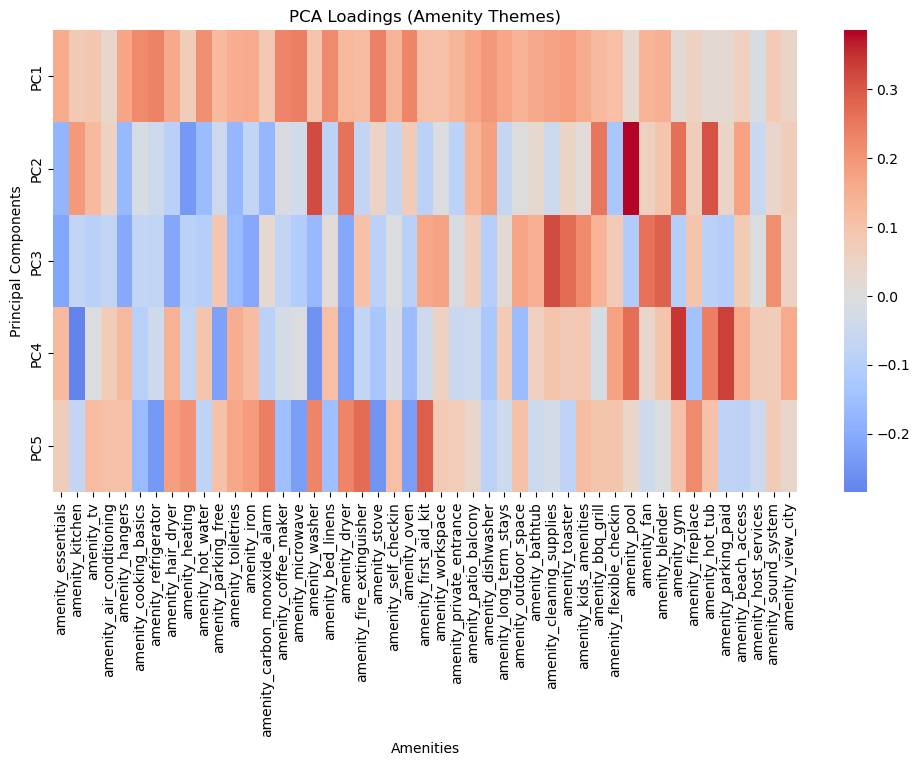

In [25]:
plt.figure(figsize=(12,6))
sns.heatmap(pca_loadings, cmap='coolwarm', center=0)

plt.title("PCA Loadings (Amenity Themes)")
plt.xlabel("Amenities")
plt.ylabel("Principal Components")

plt.show()

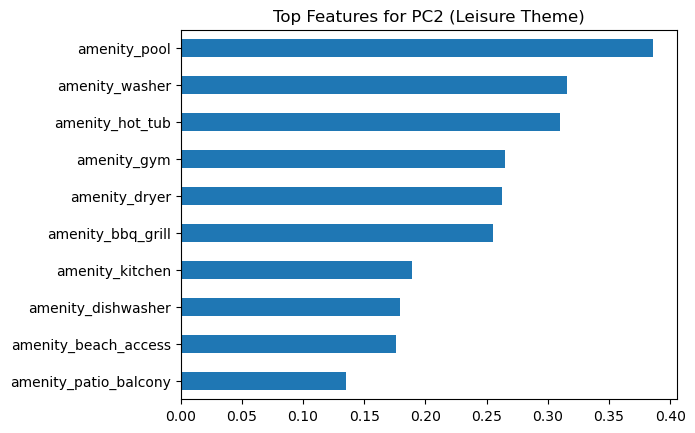

In [26]:
top_features = pca_loadings.T.sort_values(by='PC2', ascending=False).head(10)

top_features['PC2'].plot(kind='barh')
plt.title("Top Features for PC2 (Leisure Theme)")
plt.gca().invert_yaxis()
plt.show()

### Summary: 

I was curious to see how certain amenities grouped together, but I didn't get a very clear read. 
* PC1: Fully equipped, standard, livable listing
* PC2: Vacation / outdoor / leisure listing
* PC3: Multi-use living: family + longer stays + practical use (parking and kids amenities)
* PC4: Basic amenities plus a pool (didn't seem to cluster strongly)
* PC5: Basic amenities plus parking (suitable for an extended stay)

## Rare Amenity Analysis (Exploratory)


In [27]:
rare_amenities

['amenity_view_nature',
 'amenity_view_water',
 'amenity_view_other',
 'amenity_ev_charger',
 'amenity_musical_instruments',
 'amenity_game_console',
 'amenity_ski_access']

In [28]:
# --- Mean presence of each rare amenity by city ---
city_amenities = df.groupby('city')[rare_amenities].mean()

city_amenities.sort_values(by=rare_amenities, ascending=False).head(10)

,amenity_view_nature,amenity_view_water,amenity_view_other,amenity_ev_charger,amenity_musical_instruments,amenity_game_console,amenity_ski_access
city,,,,,,,
Bozeman,0.341202,0.000000,0.062232,0.047210,0.027897,0.010730,0.012876
Asheville,0.183442,0.000687,0.021642,0.041910,0.039849,0.023703,0.000687
Clark County,0.129820,0.000785,0.073987,0.052792,0.017663,0.031989,0.001276
Hawaii,0.128373,0.204636,0.068395,0.024490,0.007614,0.014720,0.000338
Santa Cruz,0.115123,0.136240,0.051090,0.094687,0.046322,0.029973,0.000681
Dever,0.099772,0.000456,0.051025,0.037813,0.051481,0.041686,0.000456
Seattle,0.093578,0.061186,0.052472,0.042811,0.038833,0.027467,0.000379
San Mateo,0.085026,0.106095,0.039880,0.055681,0.033108,0.021445,0.000376
Los Angeles,0.078970,0.024346,0.043909,0.052264,0.038535,0.019661,0.000328


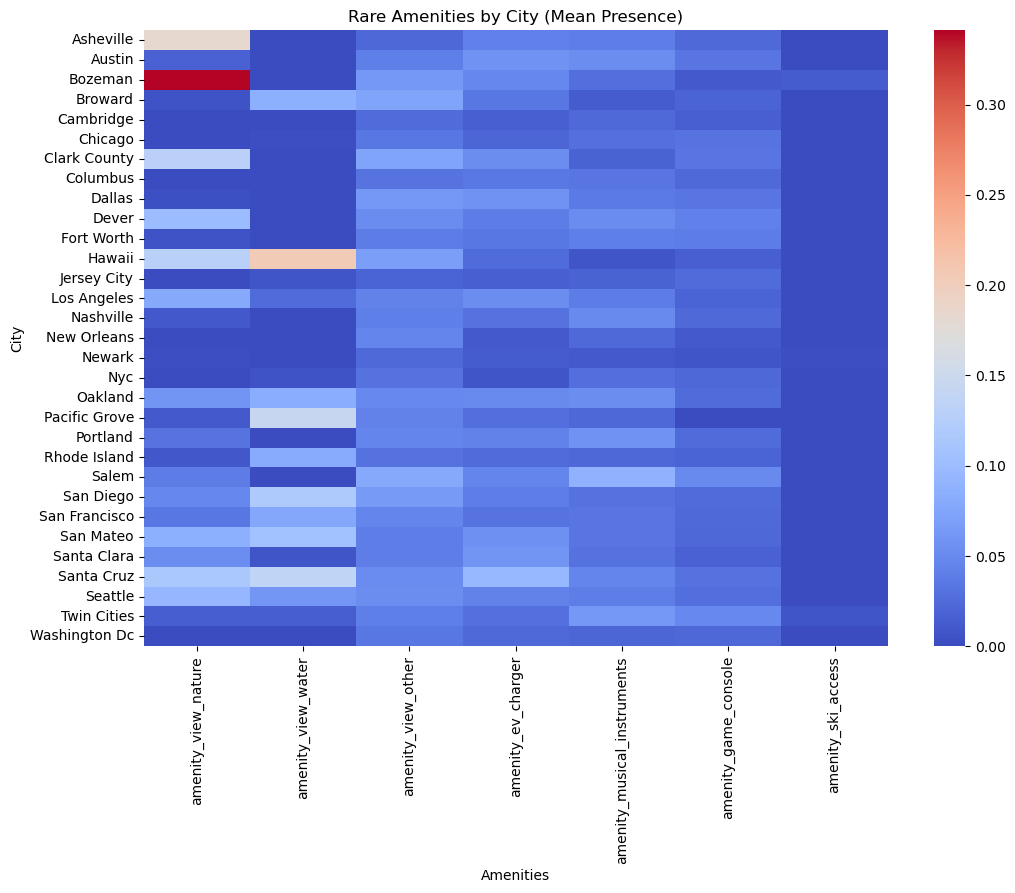

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(city_amenities, cmap='coolwarm')

plt.title("Rare Amenities by City (Mean Presence)")
plt.xlabel("Amenities")
plt.ylabel("City")

plt.show()

## Save CSV

In [30]:
df.to_csv('../data/processed/airbnb_preprocessed.csv', index=False)

print('Saved airbnb_preprocessed.csv:', df.shape)

Saved airbnb_preprocessed.csv: (210525, 82)


## Overview

In this stage, I prepared the dataset for modeling by making sure all features were in a usable format and ready for machine learning. Categorical variables like room type and amenities were already encoded during earlier steps. I confirmed that all features were numeric and consistent.


I also applied feature scaling using a StandardScaler for Ridge and Lasso regression (in next step). Finally, I split the dataset into training and testing sets (80/20) to allow for proper model evaluation and to reduce the risk of overfitting.


Overall, this step was focused on creating a clean, structured dataset that can be used reliably in the modeling phase.


<b>Next Steps:</b>
In the modeling phase, I will test different models to understand what drives Airbnb performance (bookings, potentially pricing as well). This includes building baseline linear models for interpretability, applying regularization techniques to address multicollinearity, and testing nonlinear models to capture more complex relationships.
The goal is to identify which features—such as location, bed/baths, and amenities are most predictive of demand and pricing, and to use those insights to inform what makes a high-performing listing.

<b>Overall goal:</b>
Given a specific location and market conditions, what type of Airbnb listing will consistently perform best in terms of bookings (and sustainable pricing)?

    For example: 

        For a defined area (city / zip code / radius), what combination of:

        * property size (bedrooms, bathrooms, accommodates)
        * amenity profile (baseline vs premium vs niche)
        * price range

        will maximize demand (reviews per month) while remaining competitive in that market?

        later: do images make a difference, if so, what qualities should they have? 